# SoftMax Regression

Softmax Regression, also known as Multinomial Logistic Regression, is a supervised learning classification algorithm used when the target variable has more than two classes. It is an extension of binary logistic regression, where instead of predicting the probability of one class, the model predicts the probability of every class simultaneously.

Softmax Regression model first computes a score Sk(x) for each class k, then estimates the probability of each class by applying the softmax function
Sk(x) is just like the equation for Linear Regression prediction

After computing the score of every class for the instance x, we can estimate the probability p(k) that the instance belongs to class k by running the scores through the softmax function. The function computes the exponential of every score, then normalises them by the sum of all the exponentials. The scores are generally called logits or log-odds (although they are actually unnormalized log-odds)

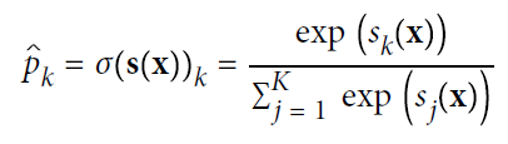

In [2]:
import numpy as np
import matplotlib.pyplot as plt

pair 1, [0->1,other->0] : -6.71 ,18.19
pair 2, [1->1,other->0] : -0.04 ,-0.32
pair 3, [2->1,other->0] : 4.43 ,-20.98


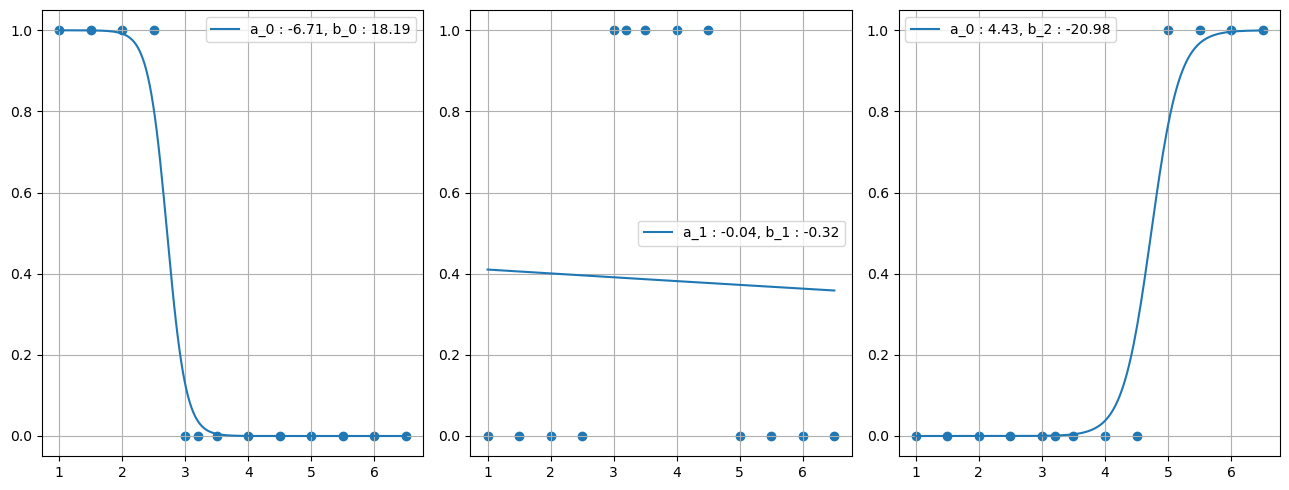

x_test           : [2.2 4.2 4.9]
softMax_probs    : [['0.98', '0.02', '0.00'], ['0.00', '0.87', '0.13'], ['0.00', '0.22', '0.78']]
Model_predictions: [0, 1, 2]


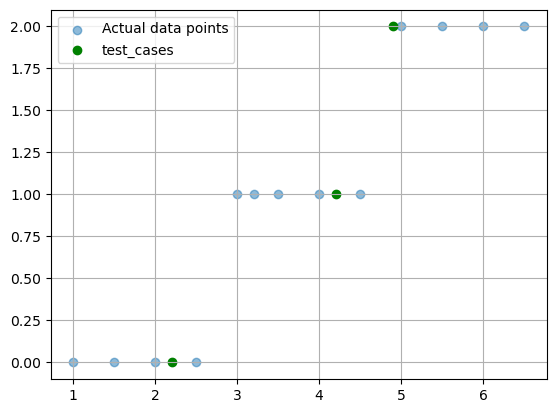

In [3]:
x = np.array([1.0,1.5,2.0,2.5,3.0,3.2,3.5,4.0,4.5,5.0,5.5,6.0,6.5])
labels = np.array([0,0,0,0,1,1,1,1,1,2,2,2,2])
m = len(x)

def get_fitt(x,y,i):
    class_new = (y == i).astype(int)
    a,b = 0.0,0.0
    itr_max = 50000
    lr = 0.05
    for itr in range(itr_max):
        p = 1/(1+np.exp(-(a*x + b)))
        da = (1/m)*(np.dot((p-class_new), x))
        db = (1/m)*(np.sum(p-class_new))
        a = a - lr*da
        b = b - lr*db
    return a,b,class_new

def soft_max_prob(a,b,a1,b1,a2,b2,x):
    y = []
    softmax_prob = []
    for ele in x:
        s_0 = np.exp(a*ele + b)/(np.exp(a*ele + b) + np.exp(a1*ele + b1) + np.exp(a2*ele + b2))
        s_1 = np.exp(a1*ele + b1)/(np.exp(a*ele + b) + np.exp(a1*ele + b1) + np.exp(a2*ele + b2))
        s_2 = np.exp(a2*ele + b2)/(np.exp(a*ele + b) + np.exp(a1*ele + b1) + np.exp(a2*ele + b2))
        max_ = max(s_0,s_1,s_2)
        softmax_prob.append([f'{s_0:.2f}',f'{s_1:.2f}',f'{s_2:.2f}'])
        if max_ == s_0: y.append(0)
        elif max_ == s_1: y.append(1)
        else: y.append(2)
    return softmax_prob,y
    
a_0,b_0,new_0 = get_fitt(x,labels,0)
a_1,b_1,new_1 = get_fitt(x,labels,1)
a_2,b_2,new_2 = get_fitt(x,labels,2)
print(f'pair 1, [0->1,other->0] : {a_0:.2f} ,{b_0:.2f}')
print(f'pair 2, [1->1,other->0] : {a_1:.2f} ,{b_1:.2f}')
print(f'pair 3, [2->1,other->0] : {a_2:.2f} ,{b_2:.2f}')

x_smooth = np.linspace(x.min(), x.max(), 200)
plt.figure(figsize=(13,5))
plt.subplot(1,3,1)
plt.grid()
plt.scatter(x,new_0)
p_smooth_0 = 1/(1+np.exp(-(a_0*(x_smooth) + b_0)))
plt.plot(x_smooth, p_smooth_0, label = f'a_0 : {a_0:.2f}, b_0 : {b_0:.2f}')
plt.legend()
plt.subplot(1,3,2)
plt.grid()
plt.scatter(x,new_1)
p_smooth_1 = 1/(1+np.exp(-(a_1*(x_smooth) + b_1)))
plt.plot(x_smooth, p_smooth_1, label = f'a_1 : {a_1:.2f}, b_1 : {b_1:.2f}')
plt.legend()
plt.subplot(1,3,3)
plt.grid()
plt.scatter(x,new_2)
p_smooth_2 = 1/(1+np.exp(-(a_2*(x_smooth) + b_2)))
plt.plot(x_smooth, p_smooth_2, label = f'a_0 : {a_2:.2f}, b_2 : {b_2:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

test_cases = np.array([2.2,4.2,4.9])
print('x_test           :', test_cases)
softmax, predictions = soft_max_prob(a_0,b_0,a_1,b_1,a_2,b_2,test_cases)
print('softMax_probs    :', softmax)
print('Model_predictions:', predictions)

plt.scatter(x,labels, alpha = 0.5, label= "Actual data points")
plt.scatter(test_cases,predictions, color = 'green', label = 'test_cases')
plt.grid()
plt.legend()
plt.show()

x_test:          : [2.2 4.2 6.2]
y_test:          : [2.9 5.  6.5]
softMax_probs    : [['0.97', '0.03', '0.00'], ['0.00', '0.86', '0.14'], ['0.00', '0.00', '1.00']]
Model_predictions: [0, 1, 2]


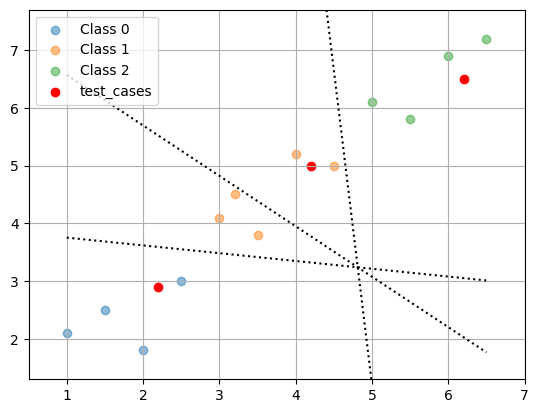

In [4]:
x = np.array([1.0,1.5,2.0,2.5,3.0,3.2,3.5,4.0,4.5,5.0,5.5,6.0,6.5])
y = np.array([2.1,2.5,1.8,3.0,4.1,4.5,3.8,5.2,5.0,6.1,5.8,6.9,7.2])
labels = np.array([0,0,0,0,1,1,1,1,1,2,2,2,2])
m = len(x)
plt.grid()
red_x,red_y,green_x,green_y,blue_x,blue_y =[],[],[],[],[],[]
for i in range(m):
    if labels[i] == 0: 
        red_x.append(x[i])
        red_y.append(y[i])
    elif labels[i] == 1:
        green_x.append(x[i])
        green_y.append(y[i])
    else:
        blue_x.append(x[i])
        blue_y.append(y[i])

plt.scatter(red_x,red_y, label='Class 0',alpha=0.5)
plt.scatter(green_x,green_y, label='Class 1',alpha=0.5)
plt.scatter(blue_x,blue_y, label='Class 2',alpha=0.5)

def get_fitt(x,y,z,i):
    class_new = (z == i).astype(int)
    a,b,c = 0.0,0.0,0.0
    itr_max = 50000
    lr = 0.05
    for itr in range(itr_max):
        p = 1/(1+np.exp(-(a*x + b*y +c)))
        da = (1/m)*(np.dot((p-class_new), x))
        db = (1/m)*(np.dot((p-class_new), y))
        dc = (1/m)*(np.sum(p-class_new))
        a = a - lr*da
        b = b - lr*db
        c = c - lr*dc
    return a,b,c,class_new

def soft_max_predict(a,b,c,a1,b1,c1,a2,b2,c2,x,y):
    pred = []
    soft = []
    for i in range(len(x)):
        s_0 = np.exp(a*x[i] + b*y[i] +c)/(np.exp(a*x[i] + b*y[i] +c) + np.exp(a1*x[i] + b1*y[i] +c1) + np.exp(a2*x[i] + b2*y[i] +c2))
        s_1 = np.exp(a1*x[i] + b1*y[i] +c1)/(np.exp(a*x[i] + b*y[i] +c) + np.exp(a1*x[i] + b1*y[i] +c1) + np.exp(a2*x[i] + b2*y[i] +c2))
        s_2 = np.exp(a2*x[i] + b2*y[i] +c2)/(np.exp(a*x[i] + b*y[i] +c) + np.exp(a1*x[i] + b1*y[i] +c1) + np.exp(a2*x[i] + b2*y[i] +c2))
        soft.append([f'{s_0:.2f}',f'{s_1:.2f}',f'{s_2:.2f}'])
        max_ = max(s_0,s_1,s_2)
        if max_ == s_0: pred.append(0)
        elif max_ == s_1: pred.append(1)
        else: pred.append(2)
    return soft, pred
    
a_0,b_0,c_0,new_0 = get_fitt(x,y,labels,0)
a_1,b_1,c_1,new_1 = get_fitt(x,y,labels,1)
a_2,b_2,c_2,new_2 = get_fitt(x,y,labels,2)

x_test = np.array([2.2,4.2,6.2])
y_test = np.array([2.9,5.0,6.5])
print('x_test:          :',x_test)
print('y_test:          :',y_test)
softmax, predictions = soft_max_predict(a_0,b_0,c_0,a_1,b_1,c_1,a_2,b_2,c_2,x_test,y_test)
print('softMax_probs    :', softmax)
print('Model_predictions:',predictions)

plt.scatter(x_test,y_test,color='red',label='test_cases')
plt.legend(loc="upper left")

x_smooth = np.linspace(x.min(), x.max(), 200)
a_0_1,b_0_1,c_0_1 = a_0 - a_1, b_0 - b_1, c_0 - c_1
a_1_2,b_1_2,c_1_2 = a_1 - a_2, b_1 - b_2, c_1 - c_2
a_0_2,b_0_2,c_0_2 = a_0 - a_2, b_0 - b_2, c_0 - c_2
plt.plot(x_smooth, -(c_0_1 + a_0_1*x_smooth)/b_0_1, color='black', linestyle='dotted')
plt.plot(x_smooth, -(c_1_2 + a_1_2*x_smooth)/b_1_2, color='black', linestyle='dotted')
plt.plot(x_smooth, -(c_0_2 + a_0_2*x_smooth)/b_0_2, color='black', linestyle='dotted')
plt.xlim(x.min() - 0.5, x.max() + 0.5)
plt.ylim(y.min() - 0.5, y.max() + 0.5)
plt.show()